### Tests to get mixup with n > 2 to work 

In [1]:
import numpy as np
import matplotlib.pyplot as plt
plt.gray()
import torch
import torchvision

import main
import util

In [2]:
'''BATCH_SIZE = 100
NUM_WORKERS = 1
transform = torchvision.transforms.transforms.Compose([
    torchvision.transforms.transforms.ToTensor()
])

trainset = torchvision.datasets.CIFAR10(root='datasets', train=True, download=True, transform=transform)
testset = torchvision.datasets.CIFAR10(root='datasets', train=False, download=True, transform=transform)

trainset, testset
trainloader = torch.utils.data.DataLoader(trainset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)
testloader = torch.utils.data.DataLoader(testset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
'''
_

''

In [137]:
### n non-overlapping random indices permutations
N = 3
L = 8

remaining_indices = [np.arange(L) for _ in range(N)]
no_overlap_perms = [-np.ones(L) for _ in range(N)]
for pick_i in range(L):
    available_indices = [np.array(a) for a in remaining_indices]
    for depth in range(N):
        
        # get a random index in the available indices
        pick = np.random.choice(available_indices[depth])
        
        no_overlap_perms[depth][pick_i] = pick
        
        # remove picked index from remaining ones
        remaining_indices[depth] = remaining_indices[depth][remaining_indices[depth] != pick]
        # remove picked index from available ones for following picks (prevents overlaps)
        available_indices = [a[a != pick] for a in available_indices]

print(no_overlap_perms)
for p1, p2 in [(p1, p2) for p1 in no_overlap_perms for p2 in no_overlap_perms if not np.array_equal(p1, p2)]:
    assert not 0 in p1 - p2

    # actually this implementation doesnt work
    

ValueError: 'a' cannot be empty unless no samples are taken

In [231]:
# random implementation with potential infinite running time
N = 10
L = 80

import time


def randomsearch_no_overlap_perms(n, length, max_seconds=10, return_elapsed=False):
    start = time.time()
    no_overlap_perms = []

    for depth in range(n):
        while ...:
            rand_perm = np.random.permutation(np.arange(length))
            if all(not 0 in p - rand_perm for p in no_overlap_perms):
                break
            elif max_seconds:
                if time.time() - start > max_seconds:
                    print("non overlapping ordering search took too long")
                    return ([], time.time() - start) if return_elapsed else []
        no_overlap_perms.append(rand_perm)
    return (no_overlap_perms, time.time() - start) if return_elapsed else no_overlap_perms

no_overlap_perms = randomsearch_no_overlap_perms(N, L, 1)

print(no_overlap_perms)
for p1, p2 in [(p1, p2) for p1 in no_overlap_perms for p2 in no_overlap_perms if not np.array_equal(p1, p2)]:
    assert not 0 in p1 - p2, (p1, p2)


non overlapping ordering search took too long
[]


In [225]:

times = -np.ones((10, 12))

def get_times_gridsearch(N_0, N_max, L_0, L_max):
    for N in range(N_0, N_max):
        for L in range(N + L_0, N + L_max):
            print(N, L)
            no_overlap_perms, elapsed = randomsearch_no_overlap_perms(N, L, max_seconds=5, return_elapsed=True)
            #print(N, L)
            times[N - 3, L - N - 10] = elapsed


for t_row in times:
    print(t_row)

[-1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1.]
[-1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1.]
[-1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1.]
[-1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1.]
[-1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1.]
[-1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1.]
[-1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1.]
[-1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1.]
[-1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1.]
[-1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1.]


array([0.04695487, 0.45166039, 0.1910944 , 0.27393246, 0.10592842,
       0.47146463, 0.36773801, 0.29701471, 0.04195166, 0.35932374,
       0.27055073, 0.1770196 ])

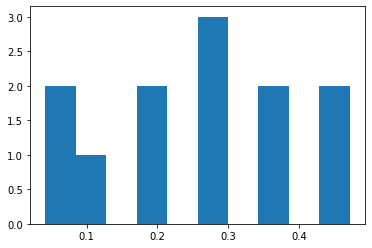

In [222]:
times_1 = get_times_gridsearch(3, 13, 10, 22)

plt.hist(times_1[5])
times_1[5]

In [245]:

randomsearch_no_overlap_perms(7, 50000, max_seconds=10, return_elapsed=False)

[array([33430, 48463, 26832, ..., 24940, 25452, 27966]),
 array([19220,  2512, 49102, ..., 25143, 10777, 17321]),
 array([15320, 44267, 36938, ..., 37516, 42494, 35219]),
 array([49789, 44019, 18359, ..., 12868, 38149, 43827]),
 array([38859, 10705, 37026, ..., 33905,  3073, 48597]),
 array([47875, 37195,  6621, ..., 10792, 41041, 29340]),
 array([26997, 23813, 13630, ..., 24147, 42623, 36247])]

In [35]:

def mixup_data_multi(x, y, lam_vect):
    batch_size = x.shape[0]
    #print(batch_size)
    indices_arr = [torch.randperm(batch_size) for _ in range(lam_vect.shape[0])]
    #print(indices_arr)
    assert lam_vect.sum() == 1, "lambda vector must sum to 1"
    mixed_x = [lam_vect[i] * x[indices_arr[i], :] for i in range(lam_vect.shape[0])]
    mixed_x = [sum(weighted) for weighted in mixed_x]
    #print(mixed_x)
    ys = [y[indices_arr[i]] for i in range(lam_vect.shape[0])]
    #print(ys)
    return np.array(mixed_x), np.array(ys), lam_vect




In [50]:
X = np.random.randint(0, 10, (3, 4, 4))
print(X[0], '\n\n', X[1], '\n\n', X[2])

[[7 7 8 8]
 [1 3 3 4]
 [2 2 3 2]
 [8 6 6 8]] 

 [[3 5 1 3]
 [4 9 7 6]
 [5 7 9 2]
 [3 0 2 4]] 

 [[0 3 9 9]
 [6 5 2 8]
 [5 1 2 8]
 [4 1 6 4]]


[[6.  6.5 7.  7. ]
 [6.5 7.5 5.5 8.5]
 [7.5 2.5 8.5 5.5]
 [7.5 9.  4.  7. ]]
[[6.  6.5 7.  7. ]
 [6.5 7.5 5.5 8.5]
 [7.5 2.5 8.5 5.5]
 [7.5 9.  4.  7. ]]
[[0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]]


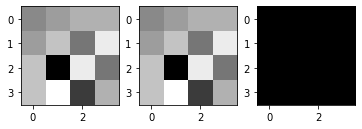

In [62]:

mixed_x, ys, lam_vect = mixup_data_multi(X, y, lam_vect=np.array([.5, .5, 0]))

mixed_x
for i, mixed_img in enumerate(mixed_x):
    print(mixed_img)
    plt.subplot(1, len(mixed_x), i+1)
    plt.imshow(mixed_img)

In [14]:
X = np.random.rand(3, 4, 4)
y = np.random.randint(0, 10, 3)

(array([[[0.72221094, 0.06791469, 0.31262737, 0.30036798],
         [0.54485198, 0.45274669, 0.64622145, 0.95036379],
         [0.686411  , 0.83549317, 0.9877424 , 0.48921694],
         [0.65184935, 0.80697986, 0.04873808, 0.39708925]],
 
        [[0.69359891, 0.37844843, 0.3784647 , 0.50355458],
         [0.67521756, 0.60863936, 0.2062935 , 0.91950577],
         [0.05505036, 0.672257  , 0.45051749, 0.34328851],
         [0.02825312, 0.83372499, 0.86634153, 0.06003202]],
 
        [[0.4930076 , 0.39989851, 0.06432918, 0.5153771 ],
         [0.1978532 , 0.30332741, 0.0504246 , 0.8898534 ],
         [0.46197546, 0.47741541, 0.08665531, 0.16758967],
         [0.07287908, 0.92346508, 0.79025956, 0.63095628]]]), array([3, 9, 7]))

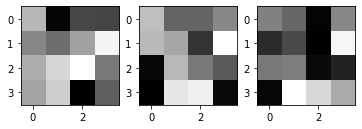

In [9]:
plt.subplot(1, 3, 1)
plt.imshow(X[0])
plt.subplot(1, 3, 2)
plt.imshow(X[1])
plt.subplot(1, 3, 3)
plt.imshow(X[2])
X, y

In [10]:
X.shape

(3, 4, 4)

3


ValueError: only one element tensors can be converted to Python scalars

In [52]:
X = np.random.randint(0, 10, (3, 4, 4))

In [54]:
X[0]

array([[1, 1, 3, 4],
       [5, 3, 7, 7],
       [9, 0, 1, 9],
       [9, 9, 5, 9]])

In [55]:
lam = np.array([0.5, 0.5, 0])

In [56]:
[X]

array([0.5, 0.5, 0. ])